<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_z_Records.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Records

Consider a sequence of random variables $X_0, X_1, \dots, X_n, \dots \sim \text{i.i.d.} F$, where $F$ is a continuous one-dimensional probability distribution. Random variables $T_j$ (times of breaking records) and $R_j$ (record values) are defined recursively as follows:

* $T_0 := 0$, $R_0 = X_0$.
* $T_{j+1} = \min\{i : X_i > R_j\}$, $R_{j+1} = X_{T_{j+1}}$.

**Tasks:**

1. Simulate the sequence $R_0, R_1, R_2, \dots, R_k$ for (say) $k = 5$ and $F = \text{Uniform}(0, 1)$. Show a few copies of such a sequence. Show empirical distributions of one-dimensional marginals (i.e. distribution of $R_1$, that of $R_2$ etc.). Estimate the covariance matrix of $R_0, R_1, R_2, \dots, R_k$.
2. Compute analytically one-dimensional marginal densities of $R_1, \dots, R_k$. Compare with the simulations.
3. Rework the previous 2 items with $F = \text{Pareto}(\alpha)$, i.e. the distribution given by:
   $$F(x) = P(X \leqslant x) = 1 - (1 + x)^{-\alpha} \quad (x > 0).$$
4. Rework these 2 items with $F = \text{Exponential}(\lambda)$.
5. Compute analytically one-dimensional marginal densities of $R_1, \dots, R_k$ for a general CDF $F$.

> **Remark:** Remember that simulating something "directly from the definition" is not always a sensible solution.

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import dirichlet
import scipy.special as sp

In [3]:
# sampling function for Records - directly from definition - non-optimal
def sampler_R(n=5):
    n_current = 0
    value_current = 0
    samples = []
    i = 0
    while True:
        i += 1
        x = np.random.rand()
        if x > value_current:
            samples.append(x)
            value_current = x
            n_current += 1
        if n_current >= n:
            break
    return samples

In [17]:
print("Example samples:")
for _ in range(5):
    print(sampler_R(6))

Example samples:
[0.37557590364227456, 0.9075280785423157, 0.9156359328231357, 0.9315070502364197, 0.9565834139002226, 0.9739906301769327]
[0.17682002977199562, 0.3657405011609277, 0.7304506257950689, 0.9210997307779412, 0.9767899530462997, 0.9982829791490994]
[0.8701386520837536, 0.9312126190276623, 0.9608667448287819, 0.9735954054735106, 0.9961048810548648, 0.9984845561529326]
[0.13233907377789678, 0.8711863960305297, 0.9117569289061382, 0.9710801919396376, 0.9899815634541492, 0.9938285631845385]
[0.9010038736088049, 0.926122833113245, 0.9584903174805012, 0.9950063999794475, 0.9974679220169783, 0.9985300028475104]


Instead of non-optimal sampling above, we can simulate $R_{j+1}$ directly using its conditional distribution given $R_j = r$. This corresponds to the original CDF $F$ left-truncated at $r$:

$$
P(R_{j+1} \leqslant x \mid R_j = r) = P(X \leqslant x \mid X > r) = \frac{F(x) - F(r)}{1 - F(r)}
$$

By applying the inverse transform method to this conditional CDF, we can sample consecutive records directly with a 100% acceptance rate, avoiding computationally expensive `while` loops.

To simulate the next record $R_{j+1}$ directly, we apply the inverse transform method to the conditional CDF. Let $U \sim \text{Uniform}(0, 1)$. We set $U$ equal to the conditional probability and solve for $R_{j+1}$:

$$U = \frac{F(R_{j+1}) - F(R_j)}{1 - F(R_j)}$$

Rearranging:

$$F(R_{j+1}) = F(R_j) + U \cdot (1 - F(R_j))$$


$$R_{j+1} = F^{-1}\Big(F(R_j) + U \cdot (1 - F(R_j))\Big)$$

This universal equation allows us to simulate the sequence of records for any continuous distribution $F$ without rejection sampling.

In [8]:
def sampler_R_optimal_universal(k, cdf, inv_cdf):
    records = np.zeros(k)

    u0 = np.random.uniform(0, 1)
    records[0] = inv_cdf(u0)

    for j in range(k-1):
        U = np.random.uniform(0, 1)
        records[j+1] = inv_cdf(cdf(records[j]) + U * (1 - cdf(records[j])))

    return records

In [18]:
print("Example samples:")
for _ in range(5):
    print(sampler_R_optimal_universal(6, cdf=lambda x: x, inv_cdf=lambda p: p))

Example samples:
[0.08214931 0.1182052  0.89567431 0.97694968 0.99179337 0.99663084]
[0.66917132 0.67684843 0.80438214 0.91468019 0.99229234 0.99584502]
[0.61681736 0.70753758 0.72961813 0.88058882 0.90883033 0.98329943]
[0.03972419 0.41979424 0.5722433  0.83069352 0.8349314  0.89516567]
[0.74590326 0.81573932 0.83385075 0.90624992 0.96106661 0.98577795]


In [19]:
# generating empirical distribution
data = [sampler_R_optimal_universal(6, cdf=lambda x: x, inv_cdf=lambda p: p) for _ in range(10000)]
data = np.array(data)

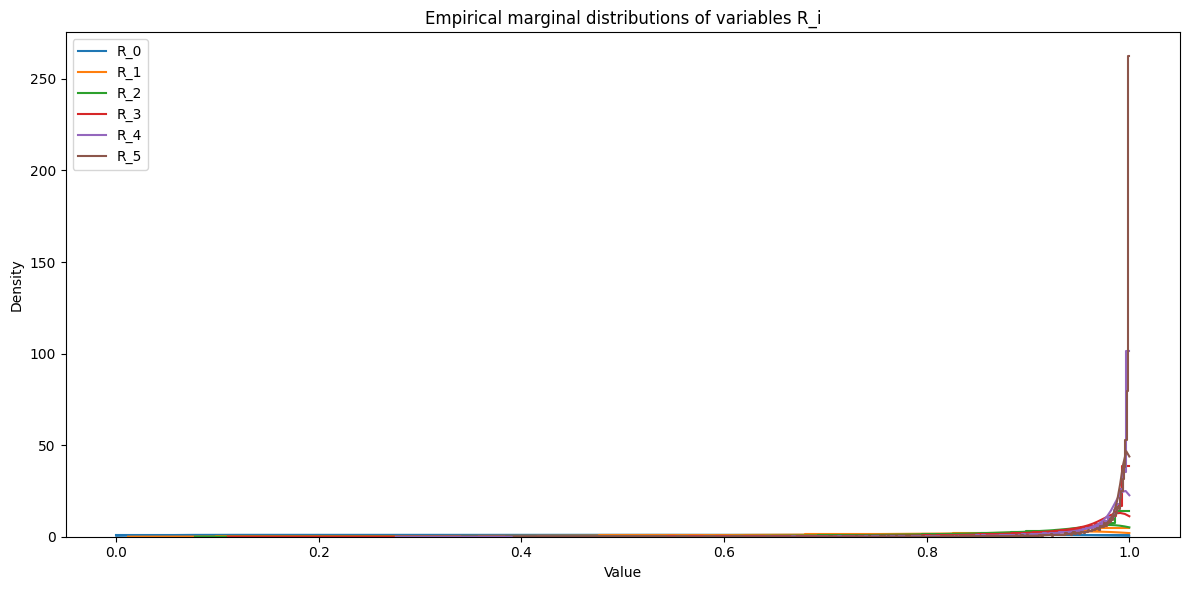

In [29]:
plt.figure(figsize=(12,6))
for i in range(6):
    sns.histplot(data[:,i], kde=True, stat='density', element="step", fill=False, label=f"R_{i}")
plt.title("Empirical marginal distributions of variables R_i")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

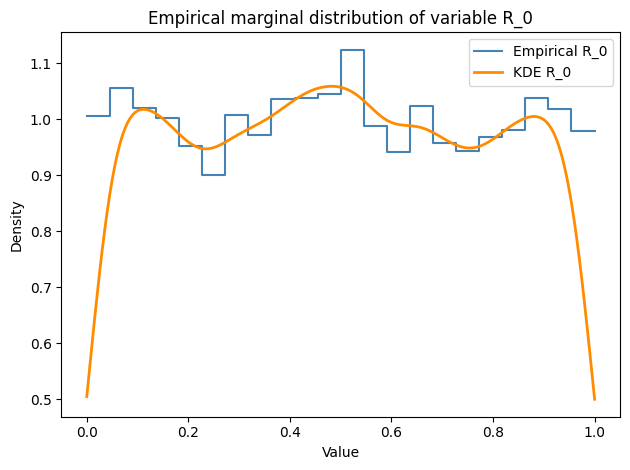

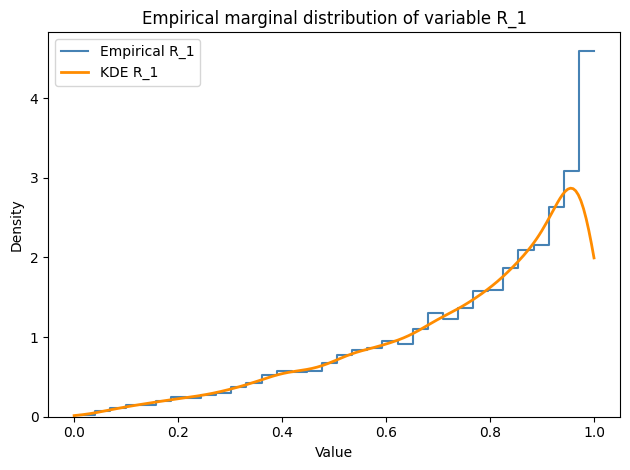

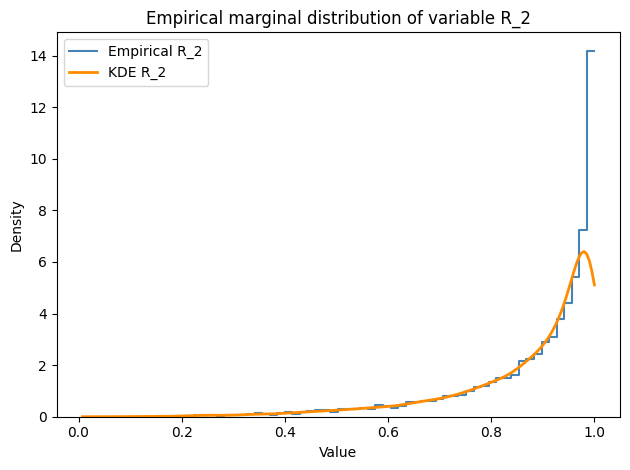

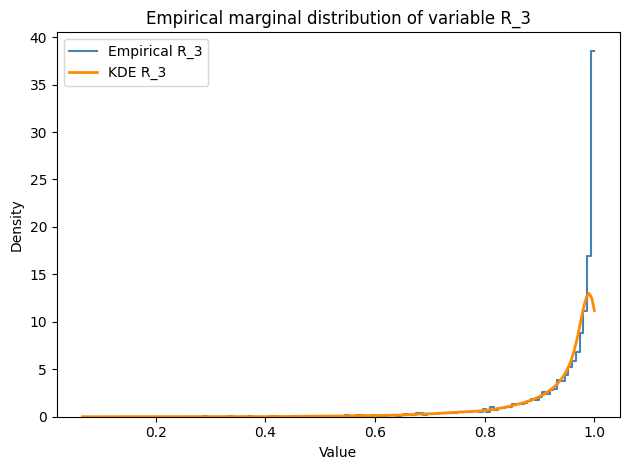

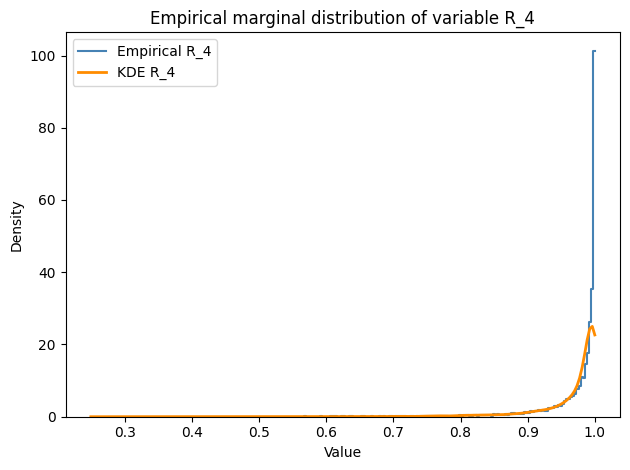

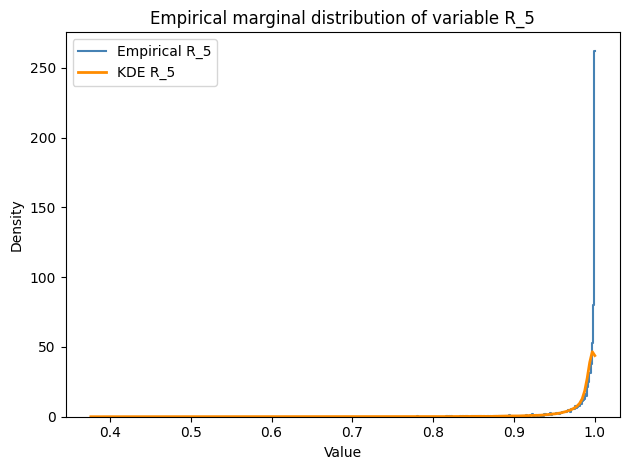

In [23]:
for i in range(6):
    sns.histplot(
        data[:, i],
        stat='density',
        element="step",
        fill=False,
        color="steelblue",
        label=f"Empirical R_{i}"
    )
    sns.kdeplot(
        data[:, i],
        color="darkorange",
        linewidth=2,
        label=f"KDE R_{i}",
        clip=(0, 1)
    )
    plt.title(f"Empirical marginal distribution of variable R_{i}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [24]:
cov_matrix = np.cov(data, rowvar=False)
print("Estimated covariance matrix:")
print(cov_matrix)

Estimated covariance matrix:
[[0.08331321 0.04229608 0.02097827 0.01048637 0.00517007 0.00261256]
 [0.04229608 0.04932182 0.02444225 0.01208141 0.00610417 0.00304635]
 [0.02097827 0.02444225 0.02171826 0.01085624 0.00538388 0.0026925 ]
 [0.01048637 0.01208141 0.01085624 0.00849475 0.00422903 0.00210522]
 [0.00517007 0.00610417 0.00538388 0.00422903 0.00313723 0.00155976]
 [0.00261256 0.00304635 0.0026925  0.00210522 0.00155976 0.00113254]]


In [ ]:
# Formula for density of R_k is:
# f_k  (-ln(1-x))^k/k!
# We will show this later

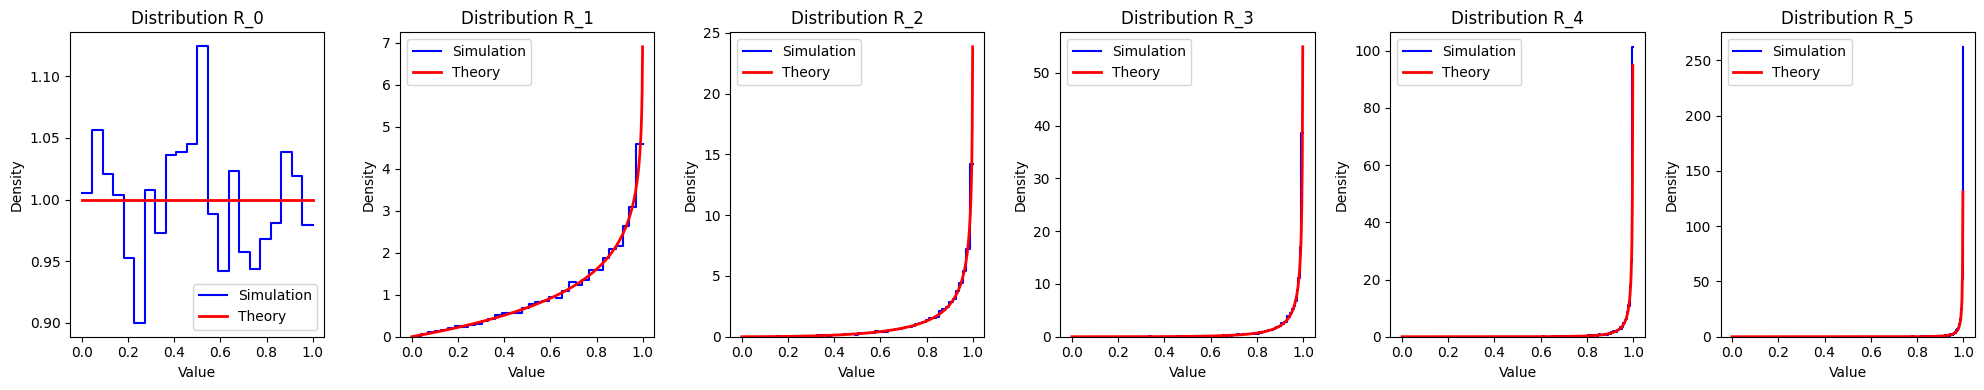

In [27]:
x_vals = np.linspace(0, 0.999, 500)
fig, axes = plt.subplots(1, 6, figsize=(20,4))

for i in range(6):
    sns.histplot(data[:,i], kde=False, stat='density', element='step', fill=False, ax=axes[i], color='blue', label='Simulation')
    y_vals = ((-np.log(1-x_vals))**i) / sp.factorial(i)
    axes[i].plot(x_vals, y_vals, color='red', linewidth=2, label='Theory')
    axes[i].set_title(f'Distribution R_{i}')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.tight_layout()
plt.show()

## Pareto distribution
---

In [28]:
alpha = 2

print("Example samples (Pareto):")
for _ in range(5):
    print(sampler_R_optimal_universal(
        6,
        cdf=lambda x: 1 - (1 + x)**(-alpha),
        inv_cdf=lambda p: (1 - p)**(-1/alpha) - 1
    ))

Example samples (Pareto):
[ 15.86668566  16.86641335  56.14213992 110.81140219 173.88476098
 208.91196675]
[7.74909908e-03 1.29739685e+00 1.31386331e+00 2.97470205e+00
 3.33292105e+00 1.30242694e+01]
[  0.93257242   2.74255813  14.53479304  29.99384005  35.71194176
 136.28006359]
[ 0.2010672   0.47682544  0.79097541  8.7948439  13.69190797 29.90706905]
[0.06409755 0.105971   0.42950563 1.04772795 1.97456955 4.31303368]


In [37]:
data = [sampler_R_optimal_universal(6, cdf=lambda x: 1 - (1 + x)**(-alpha), inv_cdf=lambda p: (1 - p)**(-1/alpha) - 1) for _ in range(10000)]
data = np.array(data)

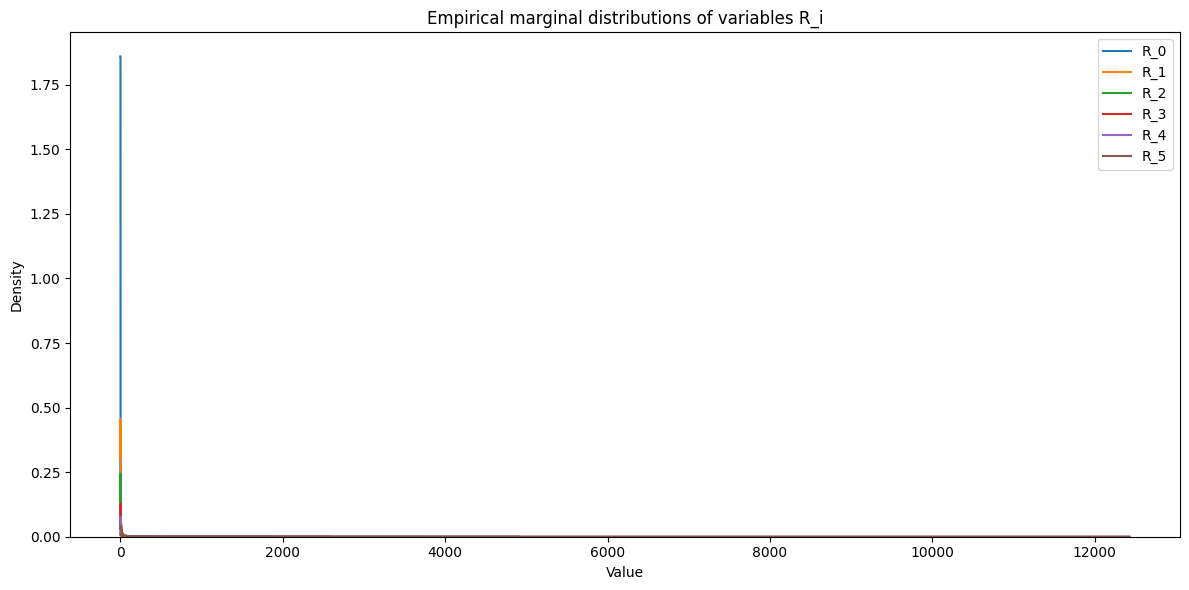

In [38]:
plt.figure(figsize=(12,6))
for i in range(6):
    sns.histplot(data[:,i], kde=True, stat='density', element="step", fill=False, label=f"R_{i}")
plt.title("Empirical marginal distributions of variables R_i")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

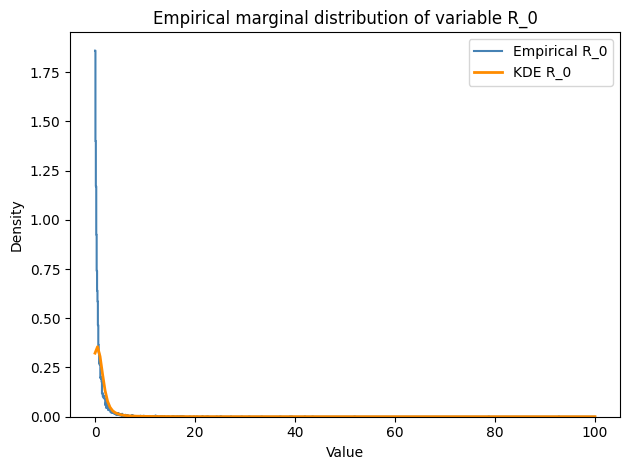

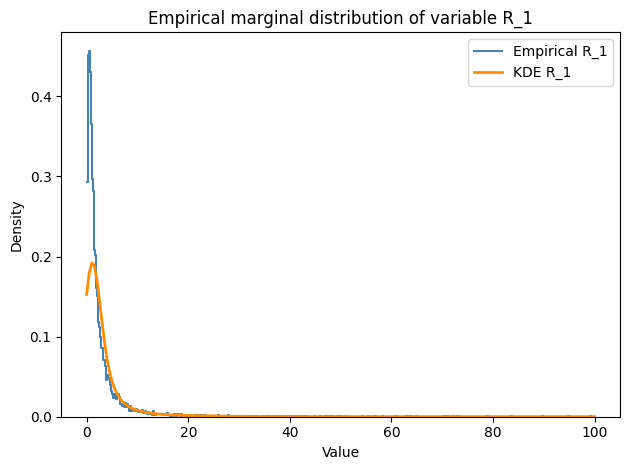

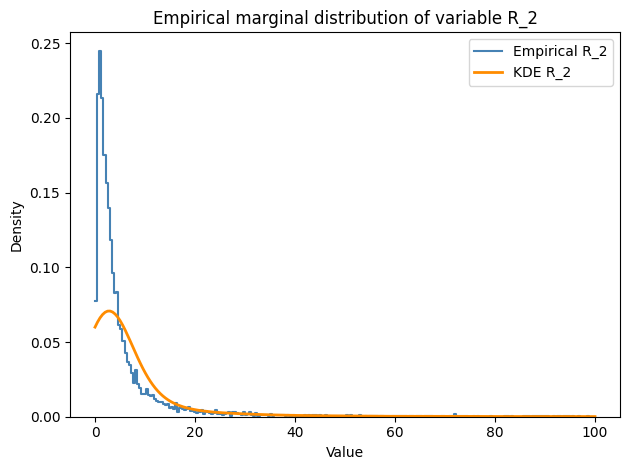

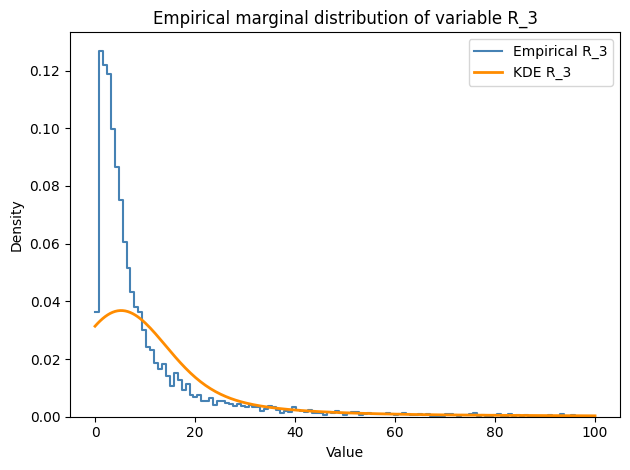

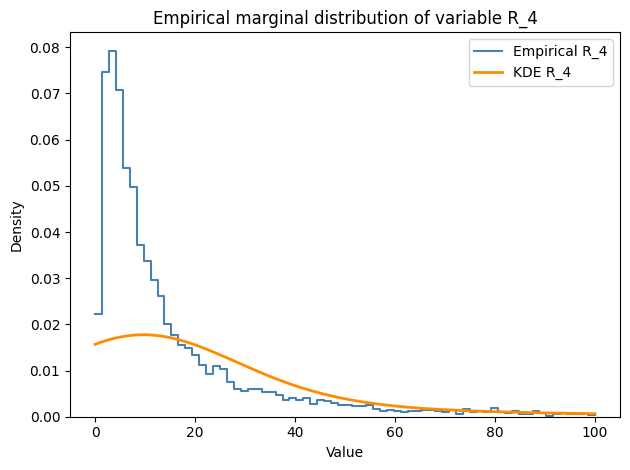

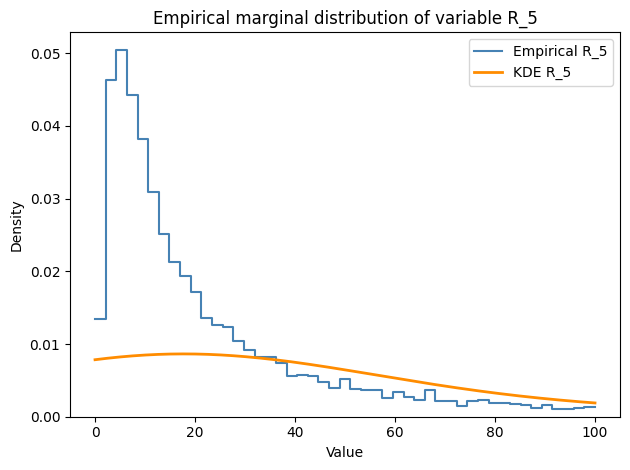

In [42]:
for i in range(6):
    sns.histplot(
        data[:, i],
        stat='density',
        element="step",
        fill=False,
        color="steelblue",
        label=f"Empirical R_{i}",
        binrange=(0,100)
    )
    sns.kdeplot(
        data[:, i],
        color="darkorange",
        linewidth=2,
        label=f"KDE R_{i}",
        clip=(0, 100)
    )
    plt.title(f"Empirical marginal distribution of variable R_{i}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [43]:
cov_matrix = np.cov(data, rowvar=False)
print("Estimated covariance matrix:")
print(cov_matrix)

Estimated covariance matrix:
[[3.10660858e+01 3.71856645e+01 4.84605977e+01 7.86780648e+01
  1.37793029e+02 1.89063003e+02]
 [3.71856645e+01 8.15316412e+01 1.40732514e+02 2.47916358e+02
  4.32075955e+02 6.98785657e+02]
 [4.84605977e+01 1.40732514e+02 7.45399359e+02 1.13459435e+03
  1.91802995e+03 3.23877864e+03]
 [7.86780648e+01 2.47916358e+02 1.13459435e+03 2.71171592e+03
  4.68783019e+03 8.92345376e+03]
 [1.37793029e+02 4.32075955e+02 1.91802995e+03 4.68783019e+03
  1.22089819e+04 2.07720064e+04]
 [1.89063003e+02 6.98785657e+02 3.23877864e+03 8.92345376e+03
  2.07720064e+04 5.36256268e+04]]


In [ ]:
# Formula for density of R_k is:
# # f_k  (-ln(1-x))^k/k!
# We will show this later

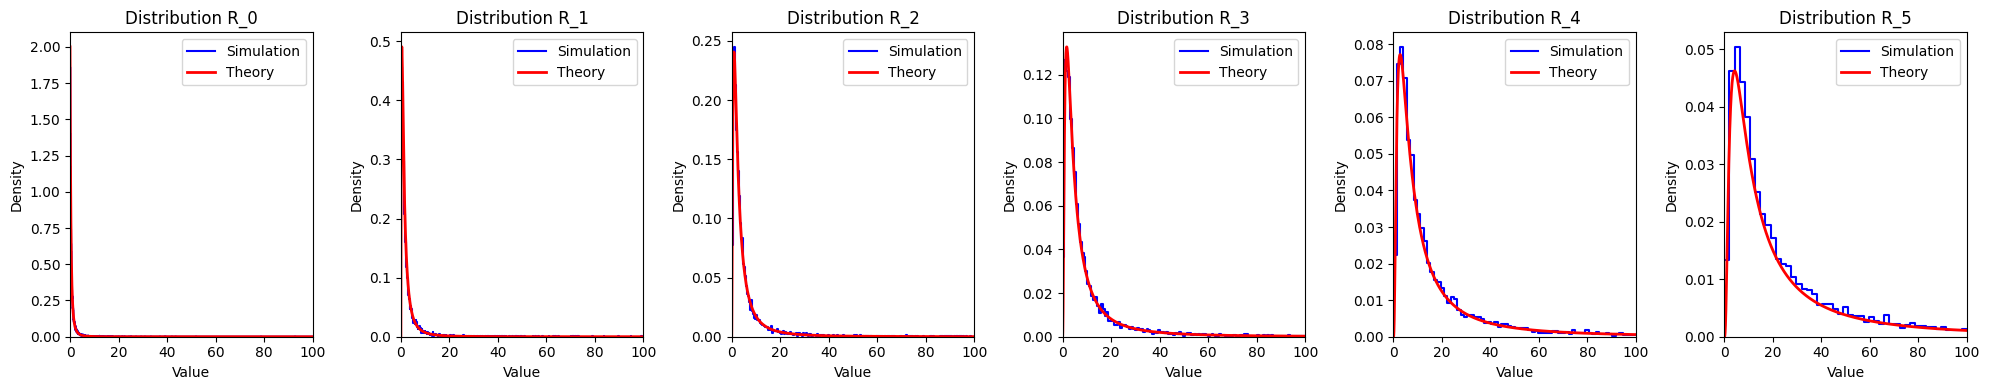

In [47]:
x_vals = np.linspace(0, 100, 5000)
fig, axes = plt.subplots(1, 6, figsize=(20,4))

for i in range(6):
    sns.histplot(
        data[:,i],
        kde=False,
        stat='density',
        element='step',
        fill=False,
        ax=axes[i],
        color='blue',
        label='Simulation',
        binrange=(0, 100)
    )

    y_vals = (alpha**(i+1) / sp.factorial(i)) * (1 + x_vals)**(-alpha - 1) * (np.log(1 + x_vals))**i
    axes[i].plot(x_vals, y_vals, color='red', linewidth=2, label='Theory')

    axes[i].set_title(f'Distribution R_{i}')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].set_xlim(0, 100)

    axes[i].legend()

plt.tight_layout()
plt.show()

## Exponential distribution
----

In [48]:
lam = 1
print("Example sample (Exponential):")
for _ in range(5):
    print(sampler_R_optimal_universal(
        6,
        cdf=lambda x: 1 - np.exp(-lam * x),
        inv_cdf=lambda p: -np.log(1 - p) / lam
    ))

Example sample (Exponential):
[ 1.19739773  2.37156946  3.34714691  3.72525427  6.88948068 10.76698238]
[0.46253013 0.60368273 1.99369711 2.52200739 3.25770034 3.46101651]
[1.15980277 1.81795434 2.77676094 2.9201904  5.08492743 5.13994283]
[0.31348783 3.78846254 3.98297134 4.02930504 5.14362638 6.67728702]
[0.23534955 1.53512621 1.88555955 2.16588895 2.39714407 2.62236685]


In [49]:
data = [sampler_R_optimal_universal(6, cdf=lambda x: 1 - np.exp(-lam * x), inv_cdf=lambda p: -np.log(1 - p) / lam) for _ in range(10000)]
data = np.array(data)

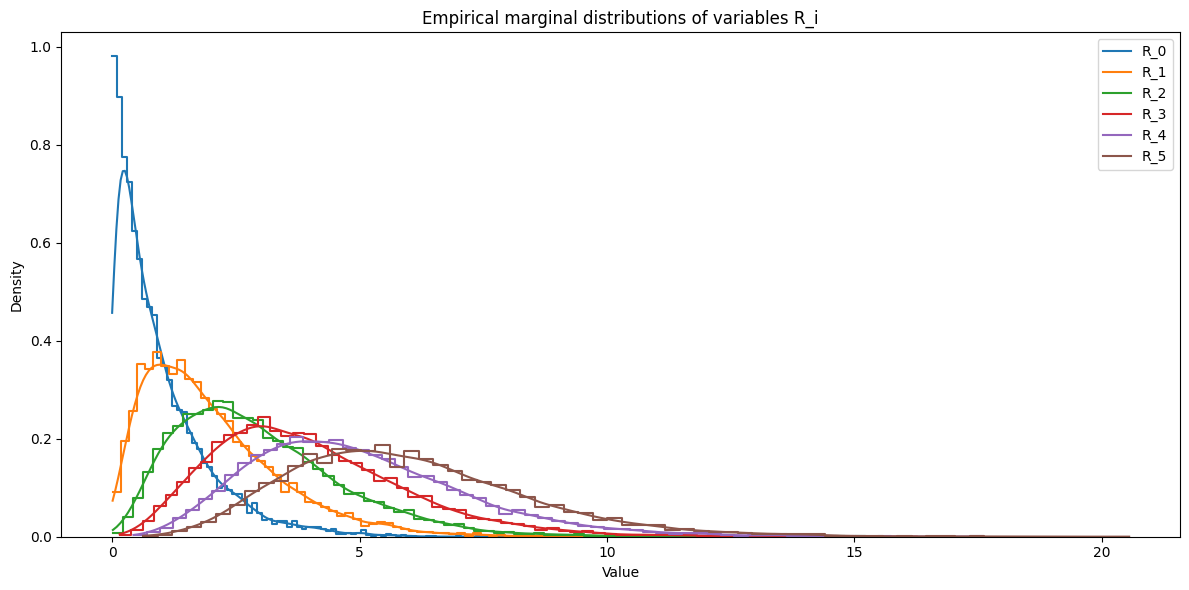

In [50]:
plt.figure(figsize=(12,6))
for i in range(6):
    sns.histplot(data[:,i], kde=True, stat='density', element="step", fill=False, label=f"R_{i}")
plt.title("Empirical marginal distributions of variables R_i")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

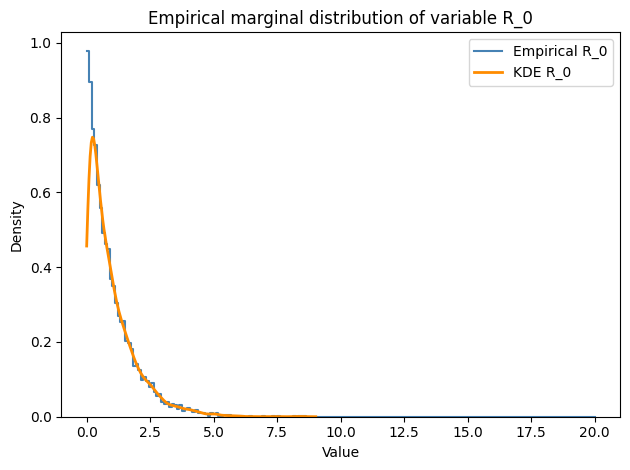

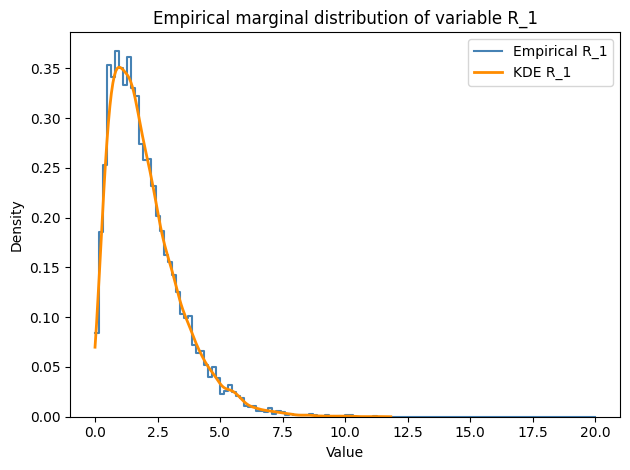

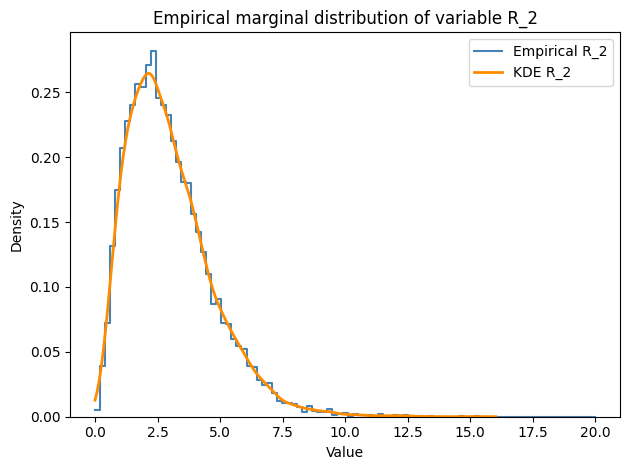

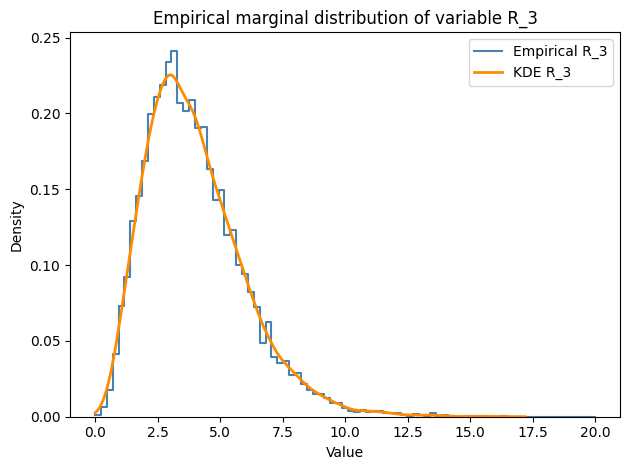

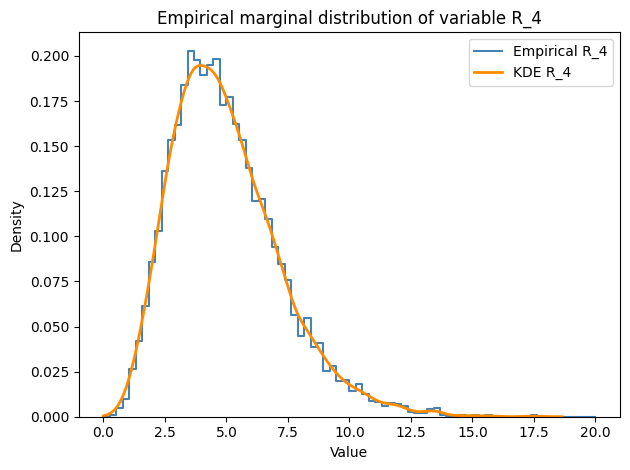

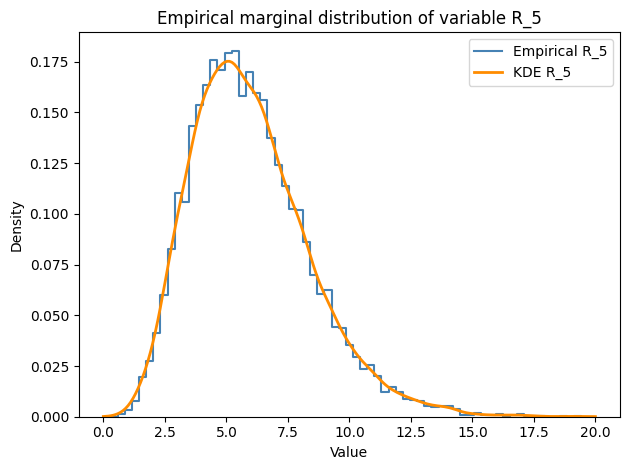

In [52]:
for i in range(6):
    sns.histplot(
        data[:, i],
        stat='density',
        element="step",
        fill=False,
        color="steelblue",
        label=f"Empirical R_{i}",
        binrange=(0,20)
    )
    sns.kdeplot(
        data[:, i],
        color="darkorange",
        linewidth=2,
        label=f"KDE R_{i}",
        clip=(0, 20)
    )
    plt.title(f"Empirical marginal distribution of variable R_{i}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
cov_matrix = np.cov(data, rowvar=False)
print("Estimated covariance matrix:")
print(cov_matrix)

In [ ]:
# Formula for density of R_k is:
# f_k  (-ln(1-x))^k/k!
# We will show this later

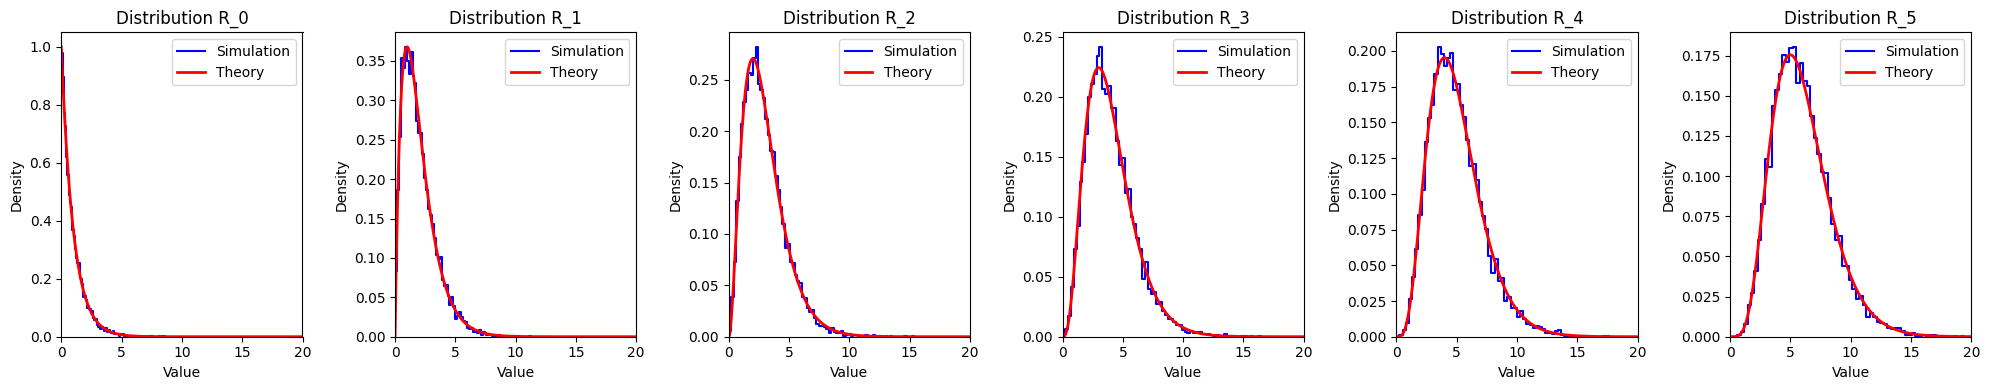

In [53]:
x_vals = np.linspace(0, 20, 5000)
fig, axes = plt.subplots(1, 6, figsize=(20,4))

for i in range(6):
    sns.histplot(
        data[:,i],
        kde=False,
        stat='density',
        element='step',
        fill=False,
        ax=axes[i],
        color='blue',
        label='Simulation',
        binrange=(0, 20)
    )

    y_vals = (lam**(i+1) * x_vals**i * np.exp(-lam * x_vals)) / sp.factorial(i)
    axes[i].plot(x_vals, y_vals, color='red', linewidth=2, label='Theory')

    axes[i].set_title(f'Distribution R_{i}')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].set_xlim(0, 20)

    axes[i].legend()

plt.tight_layout()
plt.show()

## The general formula for density of $R_k$
---

The general formula for the probability density function (PDF) of the $k$-th record value:$$f_{R_k}(x) = f(x) \cdot \frac{\left(-\ln(1 - F(x))\right)^k}{k!}$$$\rightarrow$ Derivation of the formula: Assume that the previous record took a specific value $R_{k-1} = x$. Then, the next record $R_k$ follows the distribution $F$ truncated to the interval $(x, \infty)$.From the definition of conditional probability, the density of the new record $y$ is:$$f_{R_k | R_{k-1}}(y | x) = \frac{f(y)}{1 - F(x)}, \quad y > x$$(where the denominator $1 - F(x)$ serves as a normalization factor).

$\rightarrow$ Base case for $R_1$: Let $f_{R_0}(x) = f(x)$.$$f_{R_1}(y) = \int_{-\infty}^{y} f_{R_1 | R_0}(y | x) f_{R_0}(x) \, dx$$$$f_{R_1}(y) = \int_{-\infty}^{y} \frac{f(y)}{1 - F(x)} \cdot f(x) \, dx =$$$$= f(y) \int_{-\infty}^{y} \frac{f(x)}{1 - F(x)} \, dx = f(y) \left[ -\ln(1 - F(x)) \right]_{-\infty}^{y} =$$$$= f(y) \left( -\ln(1 - F(y)) \right)$$$\rightarrow$ Inductive step for $R_{k+1}$: Assume the formula holds for $R_k$. Then for $R_{k+1}$:$$f_{R_{k+1}}(y) = \int_{-\infty}^{y} \frac{f(y)}{1 - F(x)} \cdot \frac{\left(-\ln(1 - F(x))\right)^k}{k!} \cdot f(x) \, dx =$$$$= \frac{f(y)}{k!} \int_{-\infty}^{y} \frac{\left(-\ln(1 - F(x))\right)^k \cdot f(x)}{1 - F(x)} \, dx =$$$$= \frac{f(y)}{k!} \cdot \left[ \frac{\left(-\ln(1 - F(x))\right)^{k+1}}{k+1} \right]_{-\infty}^{y} =$$$$= \frac{f(y) \cdot \left(-\ln(1 - F(y))\right)^{k+1}}{(k+1)!} \quad \blacksquare$$